# Value Iteration implementation on Frozen Lake environment

This project implements **Value Iteration** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

In [1]:
from frozen_lake_environment import generate_grid_randomly, FrozenLakeEnvironment
import numpy as np 
from matplotlib import pyplot
from visual_utils import render_policy_and_value, animate_policy_value_video

In [2]:
# let's define grid (we can we the dynamic grid generator too)
lake_grid = [["F", "S", "F", "F"],
             ["F", "H", "F", "H"],
             ["F", "H", "F", "H"],
             ["H", "F", "F", "G"]]

reward_points = {
    "S": -1,
    "G": 10,
    "F": -1,
    "H": -10
}

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=False)

# Value Iteration Algorithm Implementation

## Value Iteration algorithm

- Note that the policy, action-value function, and state-value function are generally represented as 1D lists. In this implementation, we simply represent them as 2D arrays to avoid repeatedly converting between row and column indices and a 1D representation.
- A 1D list is practically convenient when actions are deterministic and the transition matrix is represented as a 2D array, where rows represent states and columns represent actions.

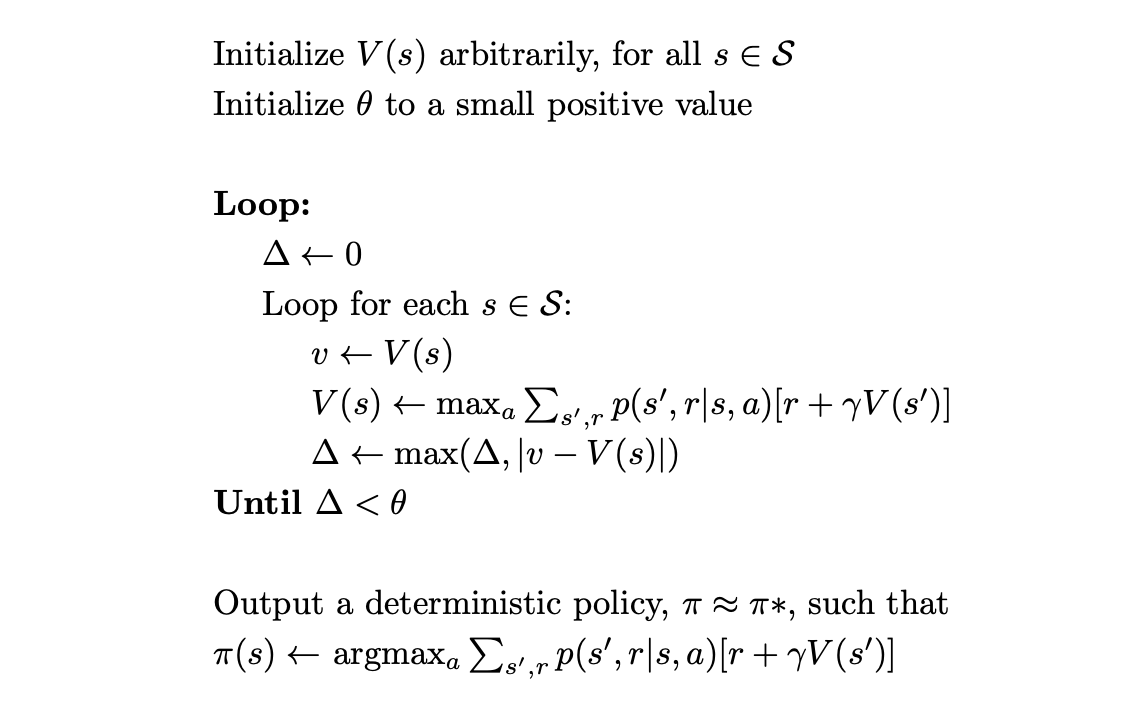

In [4]:
def value_update(environment, V, gamma=0.99, theta=1e-8):
    while True:
        delta = 0
        for r in range(len(V)):
            for c in range(len(V[0])):
                if environment.grid[r][c] in ["H", "G"]:
                    continue

                action_values = []
                for action in environment.all_action_idx:
                    q = 0
                    for transition in environment.get_transition_prob((r, c), action):
                        nr, nc = transition["new_state"]
                        q += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                    
                    action_values.append(q)
                    
                new_v = np.max(action_values).item()
                delta = max(delta, abs(V[r][c] - new_v))
                V[r][c] = new_v
        if delta < theta:
            break
    return V

In [5]:
n_rows, n_cols = frozen_lake.n_rows, frozen_lake.n_cols

policy = np.zeros((n_rows, n_cols))
V = np.zeros((n_rows, n_cols))

In [6]:
value_update(frozen_lake, V)

array([[ 4.60890549,  5.6655611 ,  6.73289   ,  5.6655611 ],
       [ 3.56281643,  0.        ,  7.811     ,  0.        ],
       [ 2.52718827,  0.        ,  8.9       ,  0.        ],
       [ 0.        ,  8.9       , 10.        ,  0.        ]])

In [7]:
def policy_update(environment, V, gamma=0.99):
    new_policy = np.zeros((environment.n_rows, environment.n_cols), dtype=np.int8)
    for r in range(len(V)):
        for c in range(len(V[0])):
            # if environment.grid[r][c] in ["H", "G"]:
            #     # terminal state; we can ignore the policy for these states
            #     continue
            # state => (r, c)
            action_values = []
            for action in environment.all_action_idx:
                q = 0
                for transition in environment.get_transition_prob((r, c), action):
                    nr, nc = transition["new_state"]
                    q += transition["prob"] * (transition["reward"] + gamma * V[nr][nc])
                action_values.append(q)
                
            new_policy[r][c] = np.argmax(action_values).item()
    return new_policy

let's do the sanity test of policy_evaluation() implementatation to make sure there is no syntax error

In [8]:
n_rows, n_cols = frozen_lake.n_rows, frozen_lake.n_cols

policy = np.zeros((n_rows, n_cols))
V = np.zeros((n_rows, n_cols))
policy

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [9]:
policy_update(frozen_lake, policy, V)

array([[ 0,  0,  0,  0],
       [ 0,  0, 16,  0],
       [ 0,  0, 16,  0],
       [ 0, 16, 32,  0]], dtype=int8)

In [10]:
def value_iteration(environment):
    n_rows = environment.n_rows
    n_cols = environment.n_cols

    V = np.zeros((n_rows, n_cols), dtype=np.float32)

    V = value_update(environment, V)
    policy = policy_update(environment, V)
        
    return policy, V, [policy], [V]

In [11]:
# run the policy iteration function to find the best greedy policy
policy, V, policy_history, V_history = value_iteration(frozen_lake)

In [12]:
len(policy_history)

1

In [13]:
policy

array([[2, 2, 1, 0],
       [3, 0, 1, 0],
       [3, 0, 1, 0],
       [0, 2, 2, 0]], dtype=int8)

In [14]:
text_policy = []
for r in range(policy.shape[0]):
    col = []
    for c in range(policy.shape[1]):
        col.append(frozen_lake.action_idx_to_name[policy[r][c].item()])
    text_policy.append(col)

In [15]:
text_policy

[['right', 'right', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['up', 'left', 'down', 'left'],
 ['left', 'right', 'right', 'left']]

# Render policy
Let's create a rendering function to visualize the policy clearly.

In [16]:
render_policy_and_value(frozen_lake, policy, V)

Policy:


,0,1,2,3
0,→,🚀 →,↓,←
1,↑,🕳️,↓,🕳️
2,↑,🕳️,↓,🕳️
3,🕳️,→,→,🏁


State-Value Function:


,0,1,2,3
0,4.61,5.67,6.73,5.67
1,3.56,0.00,7.81,0.00
2,2.53,0.00,8.90,0.00
3,0.00,8.90,10.00,0.00


# Animate policy and state value history

In [17]:
from IPython.display import HTML

In [18]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [19]:
grid = generate_grid_randomly(10, 10, n_holes=10)
grid

[['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'G', 'F', 'H', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'S', 'H', 'F', 'F']]

In [20]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=False)
policy, V, policy_history, V_history = value_iteration(frozen_lake)

In [21]:
len(policy_history)

1

In [22]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())